# Week 11 Classification Models - Logistic Regression and K Nearest Neighbors
The goal of this assignment is to introduce you to classification models.  Classification models used data to predict categorical data.  In the Logistic Regression mode it will predict one of two possible outcomes.  K-Nearest Neighbors will be used to make a prediction between the two possible outcomes but it can also be used to determine more than 2 possible outcomes.<br>

We will start by loading a few libraries we have already used to process our data.  The other libraries we will use will be load as we need them so you can see what is required to run the models.  Run the code cell below.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score

In [2]:
titanic = pd.read_csv("Titanic.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Display Data Structure
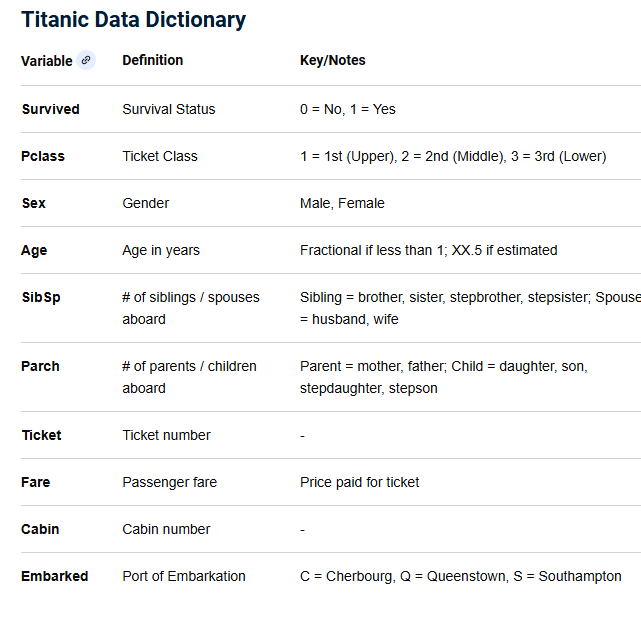

In [3]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Drop column names that will not be used in the model
```
L1 = ['column1', 'column2', 'column3']
df.drop(columns = L1, axis = 1, inplace = True)
```

In [4]:
LF = ['PassengerId', 'Name', 'Ticket']
titanic.drop(columns = LF, axis = 1, inplace = True)

In [5]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     204 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


# Determine Imbalance of data
```
df['column'].value_counts(normalize = True) * 100
```


In [7]:
titanic['Survived'].value_counts(normalize = True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

# Split the data into train and test datasets
Stratify by the Survived column to make sure you have the same makeup of those who survived

In [8]:
train_df, test_df = train_test_split(titanic, test_size = 0.3, random_state = 42, stratify = titanic['Survived'])

# Check train and test dataset distribution of target values

In [9]:
train_df['Survived'].value_counts(normalize = True) * 100

Survived
0    61.637239
1    38.362761
Name: proportion, dtype: float64

In [10]:
test_df['Survived'].value_counts(normalize = True) * 100

Survived
0    61.567164
1    38.432836
Name: proportion, dtype: float64

# Correlation of training data set

In [11]:
c_matrix = train_df.corr(numeric_only = True)
c_matrix

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.335331,-0.108771,-0.014844,0.101484,0.279393
Pclass,-0.335331,1.000000,-0.348323,0.080173,0.050443,-0.552831
Age,-0.108771,-0.348323,1.000000,-0.303841,-0.175060,0.084298
SibSp,-0.014844,0.080173,-0.303841,1.000000,0.367481,0.124474
Parch,0.101484,0.050443,-0.175060,0.367481,1.000000,0.135093
Fare,0.279393,-0.552831,0.084298,0.124474,0.135093,1.000000


# Descriptive Statistics

In [12]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Survived,623.0,0.383628,0.486660,0.00,0.0000,0.0,1.0,1.0000
Pclass,623.0,2.319422,0.830909,1.00,2.0000,3.0,3.0,3.0000
Age,504.0,30.045476,14.502377,0.42,21.0000,29.0,39.0,80.0000
SibSp,623.0,0.457464,0.964501,0.00,0.0000,0.0,1.0,8.0000
Parch,623.0,0.377207,0.841409,0.00,0.0000,0.0,0.0,6.0000
Fare,623.0,30.874003,47.760418,0.00,7.8958,13.5,30.0,512.3292


# Q1 - Data Visualization

Create a correlation heatmap to easily view the correlation matrix.
- create the figure size 5, 5
- create the heatmap using corr_matrix, annot = True, cmap = 'coolwarm', fmt = ".2f", linewidths = 0.5
- create the plt.title "Feature Correlation Heatmap"
- run show

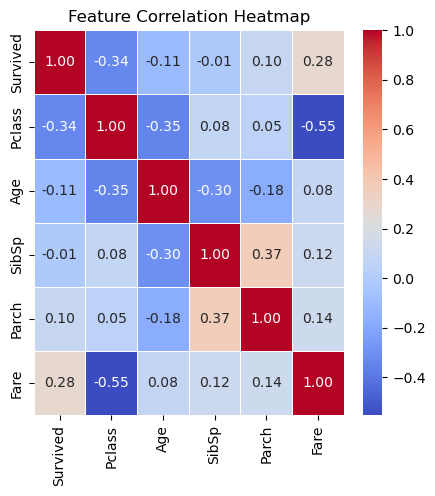

In [13]:
plt.figure(figsize = (5, 5))
sns.heatmap(c_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

# Q2 - Separate Features and Target variables for train and test datasets
- Assign 'target' from train dataset to y_train
- Assign to X_train from train dataset dropping 'target', axis = 1
- Assign 'target' from test dataset to y_test
- Assign to X_test from test dataset dropping 'target', axis = 1

In [15]:
# Q1 - Separate Features and target variables for train and test datasets
y_train = train_df['Survived']
X_train = train_df.drop('Survived', axis = 1)

y_test = test_df['Survived']
X_test = test_df.drop('Survived', axis = 1)

# Q3 - Create a pipeline for processing Numerical data
- Assign numeric column names to num_feature
- Assign num_transformer Pipeline
- Imputer missing values with name 'imputer' with SimpleImputer strategy = 'mean'
- Scale numeric values with name 'scaler' using StandardScaler()

In [16]:
n_features = X_train.select_dtypes(include = np.number).columns
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy = 'mean')),  
    ('scaler', StandardScaler())])   

# Q4 - Create a pipeline for processing Categorical data
- Assign categorical column names to cat_features
- Assign cat_transformer Pipelin
- Imputer missing values with name 'imputer' with SimpleImputer strategy = 'most_frequent'
- OneHotEncoder with name 'onehot' with handle_unknown = 'ignore'

In [17]:
cat_features = X_train.select_dtypes(include = ['object']).columns
cat_transformer = Pipeline([
     ('imputer', SimpleImputer(strategy = 'most_frequent')),
     ('onehot', OneHotEncoder(handle_unknown = 'ignore'))])

# Q5 - Creating a data preprocessing pipeline
- Assign preprocessor to ColumnTransformer
- num_transformer with name 'num' and the column names num_features
- cat_transformer with name 'cat' and the column names cat_features

In [18]:
preprocessor = ColumnTransformer([
    ('num', num_transformer, n_features),
    ('cat', cat_transformer, cat_features)])

# Q6 - Call sci-kit learn libraries
- call library from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
- call library from sklearn.linear_model import LogisticRegression
- call library from sklearn.neighbors import KNeighborsClassifier
- call library from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
- call library from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
- call library from sklearn.metrics import ConfusionMatrixDisplay

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score 
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay  

# Q7 - Create a Model for Logistic Regression and KNN
- Create a pipeline called log_pipeline
- code the name 'preprocessor' and preprocessor 
- code the name 'clf' and LogisticRegression with parameter random_state = 42.
- Create a pipeline called knn_pipeline
- code the name 'preprocessor' and preprocessor
- code the name 'clf' and KNeighborsClassifier with parameter n_neighbors = 5.

In [20]:
l_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf', LogisticRegression(random_state = 42))])
k_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf', KNeighborsClassifier(n_neighbors = 5))])           

# Q8 - Cross Validation Comparison
- define the function cross_val_comparison(models)
- create a for loop with parameters name, model in models
- create the cross_val_score for model, X, y, cv = 5 assign to variable cv_scores
- create the cross_val_predict for model, X, y, cv = 5 assign to variable y_cv_pred
- create a list called target_name with 'Normal' and 'Disease'
- print(classification_report(y, y_cv_pred, target_names = target_names))
- create the cross_val_score for model, X_test, y_test, cv = 5 assign to variable cv_scores1
- create the cross_val_predict for model, X_test, y_test, cv = 5 assign to variable y_cv_pred1
- print(classification_report(y_test, y_cv_pred1, target_names = target_names))


In [21]:
modelc = [('Logistic Regression', l_pipeline), ('KNN', k_pipeline)]

def cross_val_comparison(models):
    for name, model in models:
        cv_score = cross_val_score(model, X_train, y_train, cv = 5)
        y_cv_prd = cross_val_predict(model, X_train, y_train, cv = 5)
        print(f"{name}: ---------------------------------------------------------------------")
        print("Training Data set")
        print(f" Mean Accuracy: {cv_score.mean(): .2f}")
        print(f" Std Deviation: {cv_score.std(): .2f}\n")
        t_names = ['Normal', 'Disease']
        print(classification_report(y_train, y_cv_prd, target_names = t_names))
        cv_score1 = cross_val_score(model, X_test, y_test, cv = 5)
        y_cv_prd1 = cross_val_predict(model, X_test, y_test, cv = 5)
        print("Testing Data set")
        print(f" Mean Accuracy: {cv_score1.mean(): .2f}")
        print(f" Std Deviation: {cv_score1.std(): .2f}\n")
        print(classification_report(y_test, y_cv_prd1, target_names = t_names))

cross_val_comparison(modelc)

Logistic Regression: ---------------------------------------------------------------------
Training Data set
 Mean Accuracy:  0.80
 Std Deviation:  0.02

              precision    recall  f1-score   support

      Normal       0.83      0.85      0.84       384
     Disease       0.75      0.72      0.73       239

    accuracy                           0.80       623
   macro avg       0.79      0.78      0.79       623
weighted avg       0.80      0.80      0.80       623

Testing Data set
 Mean Accuracy:  0.81
 Std Deviation:  0.04

              precision    recall  f1-score   support

      Normal       0.82      0.88      0.85       165
     Disease       0.78      0.69      0.73       103

    accuracy                           0.81       268
   macro avg       0.80      0.78      0.79       268
weighted avg       0.80      0.81      0.80       268

KNN: ---------------------------------------------------------------------
Training Data set
 Mean Accuracy:  0.81
 Std Deviation:

# Q9 - Diagnosis: Identify Overfitting
- within the check_for_overfitting(model, name) function the following statements
- use the if statement to subtract test-acc from train_acc greater than 0.10
-  print "Result: OVERFITTING (Model is memorizing noise)"
- else
-  print "Result: GOOD GENERALIZATION"
- run the check_for_overfitting for log_pipeline and name "Logistic Regression"
- run the check_for_overfitting for knn_pipeline and name "K Nearest Neighbor"

In [86]:
def check_for_overfitting(model, name):
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    
    print(f"-----{name} Health Check ----")
    print(f"Training Accuracy: {train_acc: .2f}")
    print(f"Testing Accuracy: {test_acc: .2f}")
    print(f"Gap: {train_acc - test_acc: .2f}")
    if(train_acc - test_acc) > 0.10:
        print("Result: OVERFITTING (Model is memorizing noise)")
    else:
        print("Result: GOOD GENERALIZATION")
    print("\n")
   
check_for_overfitting(l_pipeline, "Logistic Regression")
check_for_overfitting(k_pipeline, "KNN")


-----Logistic Regression Health Check ----
Training Accuracy:  0.86
Testing Accuracy:  0.85
Gap:  0.01
Result: GOOD GENERALIZATION


-----KNN Health Check ----
Training Accuracy:  0.93
Testing Accuracy:  0.84
Gap:  0.09
Result: GOOD GENERALIZATION




# Q10 - Adjust for imbalance of the data set
- Create a Pipeline called bal_log_pipeline
- create the tuple 'preprocessor' and preprocessor
- create the tuple 'clf1' and LogisticRegression(class_weight = 'balanced', random_state = 42)
- create a Pipeline called bal_knn_pipeline
- create the tuple 'preprocessor' and preprocessor
- create the tuple 'clf1' and KNeighborsClassifer(n_neighbors = 5, weights = 'distance'))
- run the cross_val_comparison with models2 as the parameter
- run check_for_overfitting with parameters bal_log_pipeline and title "Balanced Logistic Regression"
- run check_for_overfittin with parapmetes bal_knn_pipeline and title "Balanced KNN"

In [87]:
b_log_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf1', LogisticRegression(class_weight = 'balanced', random_state = 42))])

b_knn_pipeline = Pipeline([
           ('preprocessor', preprocessor),
           ('clf1', KNeighborsClassifier(n_neighbors = 5, weights = 'distance'))])

modelcx = [('Balanced Logistic Regression', b_log_pipeline), ('Balanced KNN', b_knn_pipeline)]
cross_val_comparison(modelcx)
check_for_overfitting(b_log_pipeline, "Balanced Logistic Regression")
check_for_overfitting(b_knn_pipeline, "Balanced KNN")

Balanced Logistic Regression: ---------------------------------------------------------------------
Training Data set
 Mean Accuracy:  0.83
 Std Deviation:  0.05

              precision    recall  f1-score   support

      Normal       0.85      0.80      0.82       349
     Disease       0.82      0.87      0.84       368

    accuracy                           0.83       717
   macro avg       0.84      0.83      0.83       717
weighted avg       0.84      0.83      0.83       717

Testing Data set
 Mean Accuracy:  0.85
 Std Deviation:  0.02

              precision    recall  f1-score   support

      Normal       0.85      0.84      0.85       150
     Disease       0.85      0.86      0.86       158

    accuracy                           0.85       308
   macro avg       0.85      0.85      0.85       308
weighted avg       0.85      0.85      0.85       308

Balanced KNN: ---------------------------------------------------------------------
Training Data set
 Mean Accuracy:  0.

# Function for print_confusion_matrix function

In [88]:
def print_confusion_matrix(modelx, X_train, y_train, X_test, y_test, cv, title):
    y_cv_pred_train = cross_val_predict(modelx, X_train, y_train, cv = 5)
    print("--- "+title+": Cross-Validated Report - Training ---")
    
    cm = confusion_matrix(y_train, y_cv_pred_train, normalize = 'true') * 100
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap = plt.cm.Reds)
    plt.title(title+" CV Confusion Matrix")
    plt.show()
    y_cv_pred_test = cross_val_predict(modelx, X_test, y_test, cv = 5)

    print("--- "+title+": Cross-Validated Report - Test---")
    
    cm = confusion_matrix(y_test, y_cv_pred_test, normalize = 'true') * 100
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=['No Disease', 'Heart Disease'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title+" CV Confusion Matrix")
    plt.show()


#  Q11 - Run Confusion Matrix for each model
- in a Code cell run print_confusion_matrix for log_pipeline for training features, training target, Testing features,and Testing target cv = 5, and "Logistic Regression"
- in a new Code cell run print_confusion_matrix for knn_pipeline for training features, training target, Testing features, and testing target cv = 5, "K Nearest Neighbors"
- in a new Code cell run print_confusion_matrix for bal_log_pipeline for training features, training target, Testing features, and testing target, cv = 5, "Balanced Logistic Regression"
- in a new Code cell run print_confusion_matrix for bal_knn_pipeline for training features, training target, Testing features, and testing target, cv = 5, "Balanced K Nearest Neighbors"

--- Logistic Regression: Cross-Validated Report - Training ---


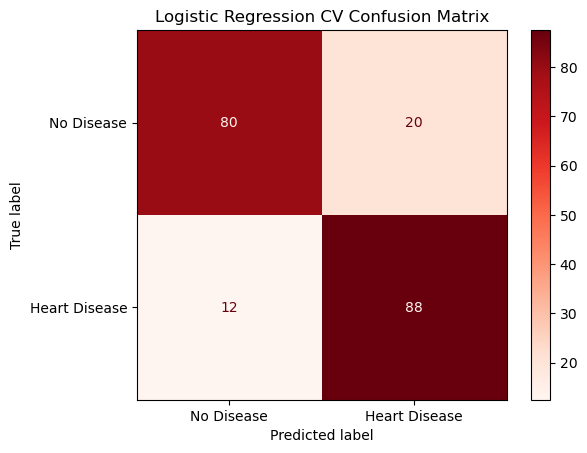

--- Logistic Regression: Cross-Validated Report - Test---


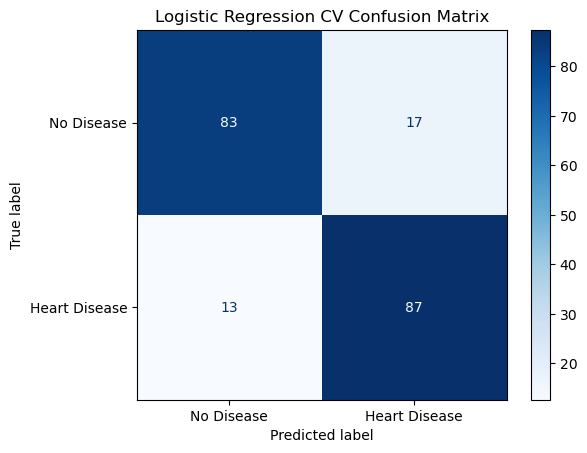

In [89]:
print_confusion_matrix(l_pipeline, X_train, y_train, X_test, y_test, 5, "Logistic Regression")

--- K Nearest Neighbor: Cross-Validated Report - Training ---


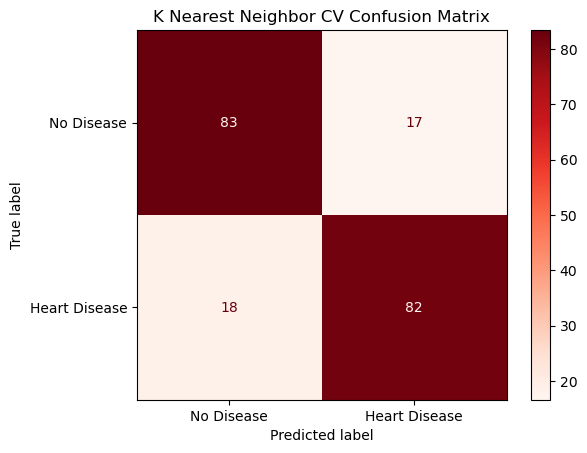

--- K Nearest Neighbor: Cross-Validated Report - Test---


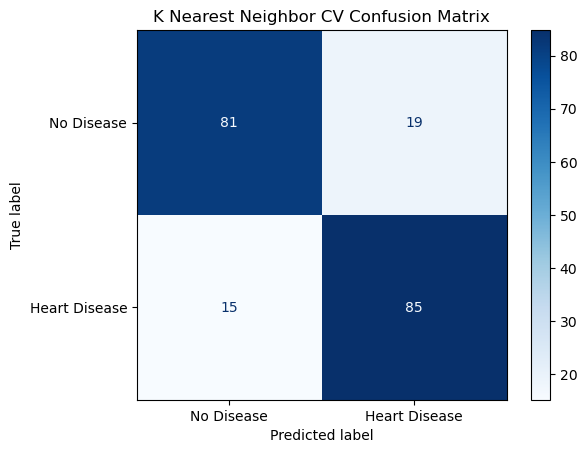

In [90]:
print_confusion_matrix(l_pipeline, X_train, y_train, X_test, y_test, 5, "Logistic Regression")

--- Balanced Logistic Regression: Cross-Validated Report - Training ---


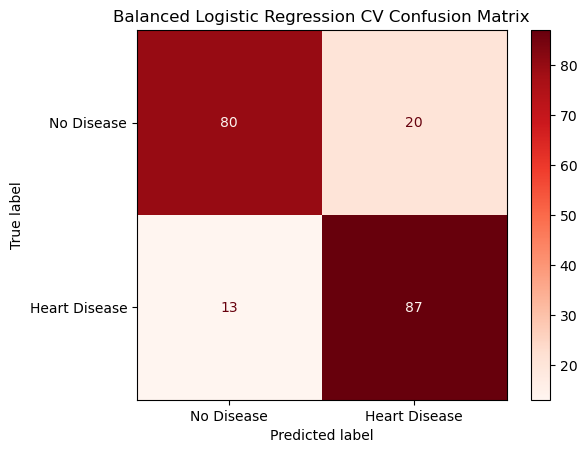

--- Balanced Logistic Regression: Cross-Validated Report - Test---


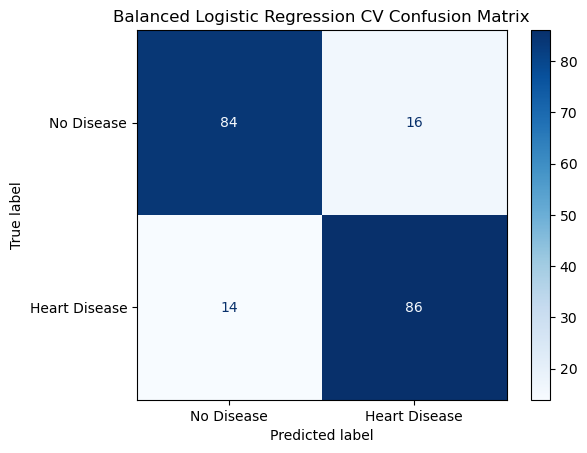

In [91]:
print_confusion_matrix(b_log_pipeline, X_train, y_train, X_test, y_test, 5, "Balanced Logistic Regression")

--- Balanced K Nearest Neighbor: Cross-Validated Report - Training ---


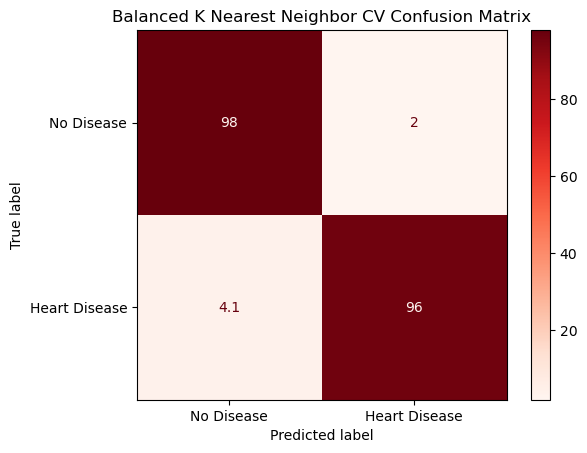

--- Balanced K Nearest Neighbor: Cross-Validated Report - Test---


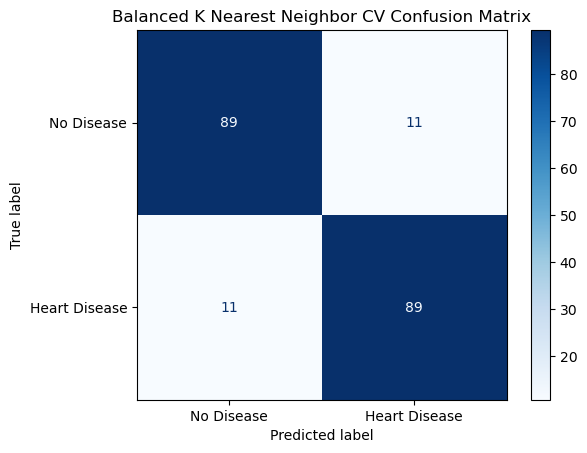

In [92]:
print_confusion_matrix(b_knn_pipeline, X_train, y_train, X_test, y_test, 5, "Balanced K Nearest Neighbor")